<a href="https://colab.research.google.com/github/fitridianamusa/Praktikum-Analisis-Deret-Waktu/blob/main/Tugas_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [2]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1054)      # 4 digit terakhir NIM
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5 + 54
beta0 = 10 + 54
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


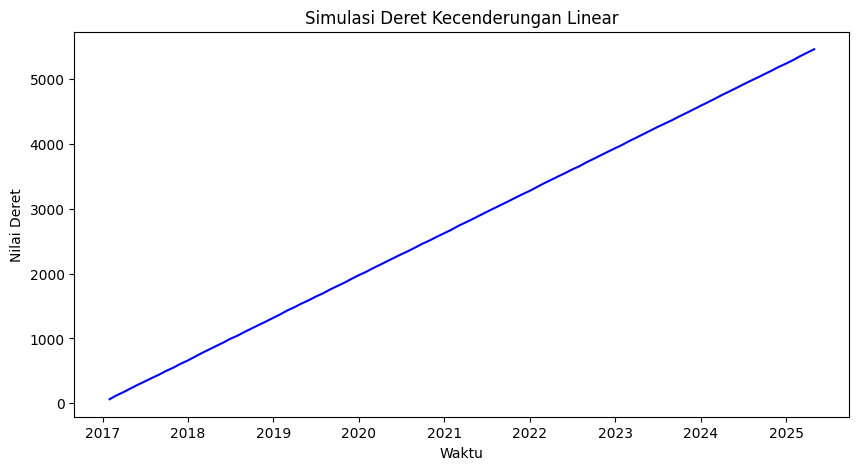

In [3]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

1. Cek apakah ada korelasi antar pengamatan? \
Jawaban: \
Dari plot tersebut terlihat adanya korelasi antar pengamatan. Hal ini dapat dilihat dari nilai deret yang terus meningkat dari waktu ke waktu. Jadi, ketika nilai pada waktu sebelumnya tinggi, nilai pada waktu berikutnya juga cenderung lebih tinggi. Pola ini menunjukkan adanya hubungan positif antar pengamatan, yang juga dipengaruhi oleh kecenderungan linear pada data.

In [4]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [5]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.544e+07
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          2.97e-290
Time:                        06:51:34   Log-Likelihood:                -200.30
No. Observations:                 100   AIC:                             404.6
Df Residuals:                      98   BIC:                             409.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           63.7422      0.360    177.262   

2. Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli? \
Jawaban: \
$β_0$ yang digunakan dalam pembangkitan data adalah: 10+54=64\
$β_1$ yang digunakan dalam pembangkitan data adalah: 0.5+54=54.5\
Maka model yang digunakan untuk pembangkitan data adalah:\
Jadi model asli yang digunakan untuk membangkitkan data adalah:\
$$Y_t = 64 + 54.5t + ε_t$$\
Lalu model hasil regresi yang diperoleh yaitu:\
$$\hat{Y}_t = 63.7422 + 54.5062t $$\
Sehingga, hasil pengepasan model regresi menghasilkan nilai parameter yang sangat dekat dengan parameter asli. Nilai intercept asli adalah 64, sedangkan hasil estimasinya sebesar 63,7422. Sementara itu, nilai slope asli sebesar 54,5 dan hasil estimasinya sebesar 54,5062. Perbedaan kecil tersebut terjadi karena pada data simulasi ditambahkan ingar acak (noise).
	​




---



3. Apakah model regresi yang dipaskan sudah bagus?\
Jawaban: \
Model regresi yang dipaskan sudah sangat baik. Nilai $R^2$ sebesar 1,000 menunjukkan bahwa hampir seluruh variasi nilai deret dapat dijelaskan oleh waktu. Selain itu, nilai parameter hasil estimasi sangat dekat dengan parameter asli dan koefisien waktu juga signifikan. Dengan demikian, model regresi linear sudah sesuai untuk menggambarkan kecenderungan pada data simulasi tersebut.

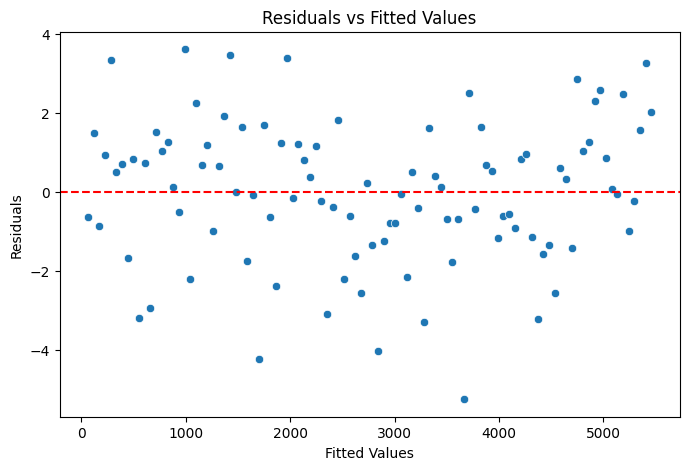

In [6]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


4. Apa interpretasi dari plot tersebut?\
Jawaban:\
Dari plot residual terhadap nilai prediksi, terlihat bahwa titik-titik residual menyebar secara acak di sekitar garis nol dan tidak membentuk pola tertentu. Sebarannya juga relatif sama dari nilai prediksi yang kecil sampai yang besar. Hal ini menunjukkan bahwa model regresi linear sudah cukup sesuai untuk menggambarkan pola data.

In [7]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.8741


5. Apa kesimpulan dari nilai uji Breusch Pagan tersebut?\
Jawaban:\
Nilai p-value uji Breusch-Pagan sebesar 0,8741, lebih besar dari 0,05. Oleh karena itu, tidak terdapat bukti adanya heteroskedastisitas pada residual. Dengan demikian, varians residual dapat dianggap konstan atau memenuhi asumsi homoskedastisitas.

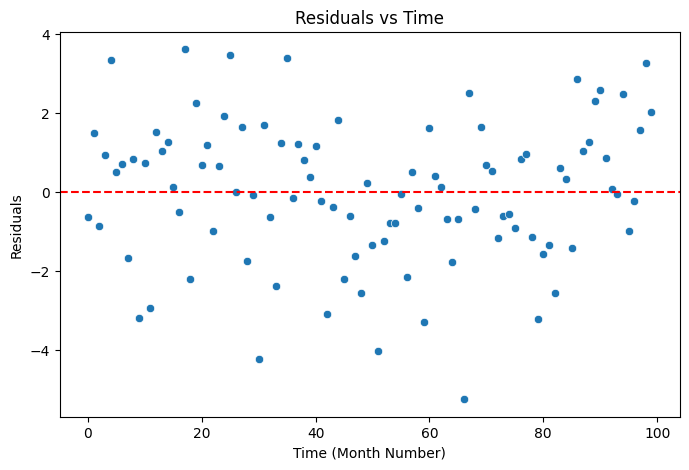

In [8]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

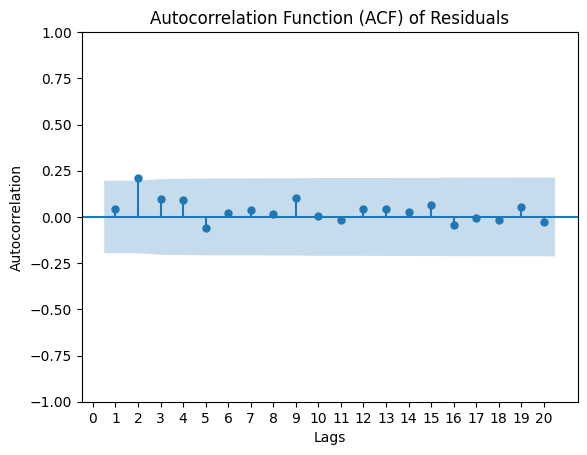

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


6. Apa yang dapat Anda simpulkan dari plot di atas?\
Jawaban:\
Dari plot ACF residual terlihat bahwa hampir seluruh nilai autokorelasi berada di dalam batas kepercayaan. Hal ini menunjukkan bahwa residual tidak memiliki pola hubungan yang kuat antar waktu. Dengan demikian, residual dapat dianggap cukup acak dan model sudah mampu menangkap pola utama pada data.

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.169171   0.680850
2    4.675116   0.096563
3    5.626090   0.131289
4    6.498161   0.164906
5    6.865524   0.230835
6    6.903258   0.329887
7    7.057455   0.422922
8    7.080339   0.527990
9    8.247025   0.509457
10   8.249281   0.604502
11   8.288500   0.687251
12   8.477089   0.746825
13   8.713434   0.794226
14   8.804110   0.843391
15   9.336384   0.859282
16   9.593382   0.886983
17   9.601836   0.919472
18   9.646930   0.942823
19  10.007779   0.952754


7. Apa kesimpulan dari hasil uji Ljung-Box tersebut?\
Jawaban:\
Hasil uji Ljung-Box menunjukkan bahwa seluruh p-value pada lag yang diuji lebih besar dari 0,05. Oleh karena itu, tidak terdapat autokorelasi yang signifikan pada residual. Hal ini menunjukkan bahwa residual sudah cukup acak, sehingga model telah mampu menangkap pola utama pada data.

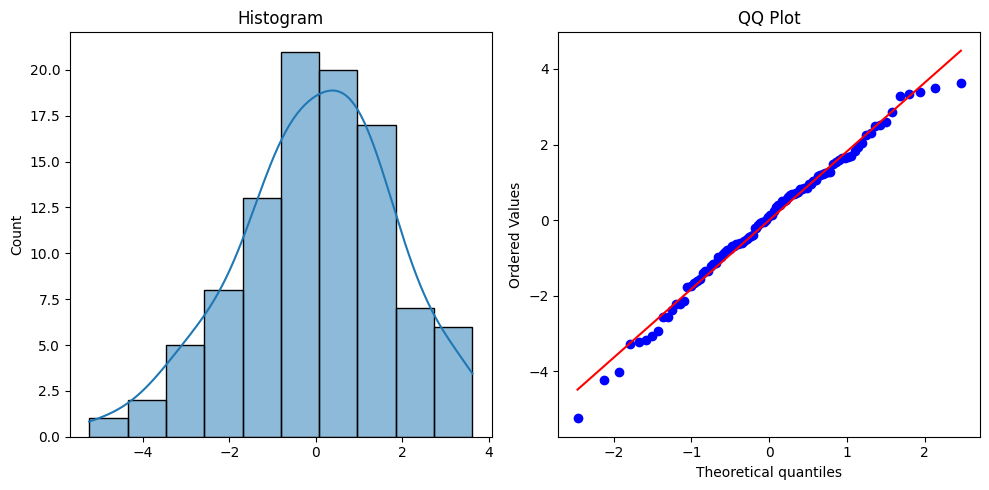

In [11]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

8. Apa kesimpulan Anda berdasarkan plot di atas?\
Jawaban:\
Berdasarkan histogram dan QQ plot, residual dapat dikatakan cukup mendekati distribusi normal. Hal ini terlihat dari bentuk histogram yang relatif menyerupai kurva lonceng dan titik-titik pada QQ plot yang sebagian besar mengikuti garis diagonal. Meskipun terdapat sedikit penyimpangan pada bagian ujung, secara umum asumsi normalitas residual masih cukup terpenuhi.

In [12]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9878878026739134, p-value = 0.4999715935733859


9. Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?\
Jawaban:\
Ya, kesimpulan dari uji Shapiro-Wilk sama dengan kesimpulan berdasarkan histogram dan QQ plot. Nilai p-value sebesar 0,5000 lebih besar dari 0,05, sehingga residual dapat dianggap berdistribusi normal. Hasil ini sesuai dengan histogram yang relatif menyerupai kurva normal dan titik-titik pada QQ plot yang sebagian besar mengikuti garis diagonal.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [13]:
# Menentukan parameter simulasi
np.random.seed(1054)
n_periods = 120
beta_0, beta_1, beta_2 = 50 + 54, 0.5 + 54, 0.02 + 54
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

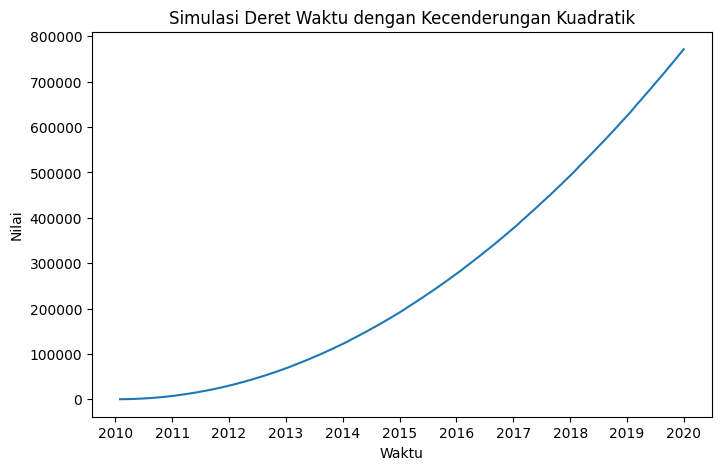

In [14]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

In [15]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.094e+10
Date:                Thu, 03 Sep 2026   Prob (F-statistic):               0.00
Time:                        06:52:16   Log-Likelihood:                -430.80
No. Observations:                 120   AIC:                             867.6
Df Residuals:                     117   BIC:                             876.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        105.8239      2.392     44.246      0.0

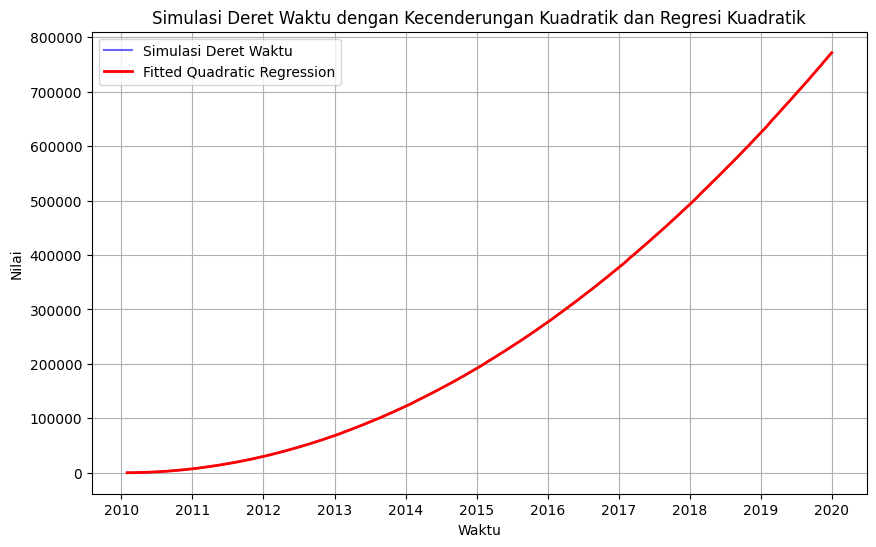

In [16]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

10. Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi!\
Jawaban:\
Berdasarkan hasil pemeriksaan residual, model regresi kuadratik sudah memenuhi asumsi. Residual memiliki varians yang relatif konstan karena p-value uji Breusch-Pagan lebih besar dari 0,05. Selain itu, tidak terdapat autokorelasi pada residual, yang terlihat dari nilai Durbin-Watson sebesar 1,999 dan hasil uji Ljung-Box dengan p-value lebih besar dari 0,05. Residual juga dapat dianggap berdistribusi normal karena p-value uji Shapiro-Wilk lebih besar dari 0,05. Dengan demikian, model regresi kuadratik yang dipaskan sudah cukup baik dan memenuhi asumsi.

In [17]:
# cek asumsi model regresi kuadratik
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

# Residual
residual_quad = model_quad.resid

# 1. Shapiro-Wilk
stat_shapiro, p_shapiro = shapiro(residual_quad)

print("=== Uji Shapiro-Wilk ===")
print(f"Statistik uji = {stat_shapiro:.4f}")
print(f"P-value       = {p_shapiro:.4f}")


# 2. Breusch-Pagan
bp_test = het_breuschpagan(residual_quad, X)

print("\n=== Uji Breusch-Pagan ===")
print(f"LM Statistic = {bp_test[0]:.4f}")
print(f"P-value      = {bp_test[1]:.4f}")


# 3. Ljung-Box
lb_test = acorr_ljungbox(
    residual_quad,
    lags=[12],
    return_df=True
)

print("\n=== Uji Ljung-Box ===")
print(lb_test)


# 4. Durbin-Watson
dw = durbin_watson(residual_quad)

print("\n=== Durbin-Watson ===")
print(f"Statistik uji = {dw:.4f}")

=== Uji Shapiro-Wilk ===
Statistik uji = 0.9870
P-value       = 0.3054

=== Uji Breusch-Pagan ===
LM Statistic = 0.0701
P-value      = 0.9656

=== Uji Ljung-Box ===
     lb_stat  lb_pvalue
12  7.433822   0.827665

=== Durbin-Watson ===
Statistik uji = 1.9994


Dari hasil uji tersebut, model kecenderungan kuadratik sudah memenuhi asumsi regresi.

- Shapiro-Wilk menghasilkan p-value 0,3054 > 0,05, jadi residual dapat dianggap berdistribusi normal.
- Breusch-Pagan menghasilkan p-value 0,9656 > 0,05, sehingga tidak terdapat indikasi heteroskedastisitas. Artinya, varians residual relatif konstan.
- Ljung-Box menghasilkan p-value 0,8277 > 0,05, sehingga tidak terdapat autokorelasi yang signifikan pada residual.
- Durbin-Watson = 1,9994, nilainya sangat dekat dengan 2, sehingga juga menunjukkan bahwa tidak ada indikasi autokorelasi yang kuat.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [18]:
# Menentukan parameter simulasi
np.random.seed(1054)
n_periods = 120
beta0, beta1, beta2 = 50 + 54,-25 + 54, -2 + 54
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


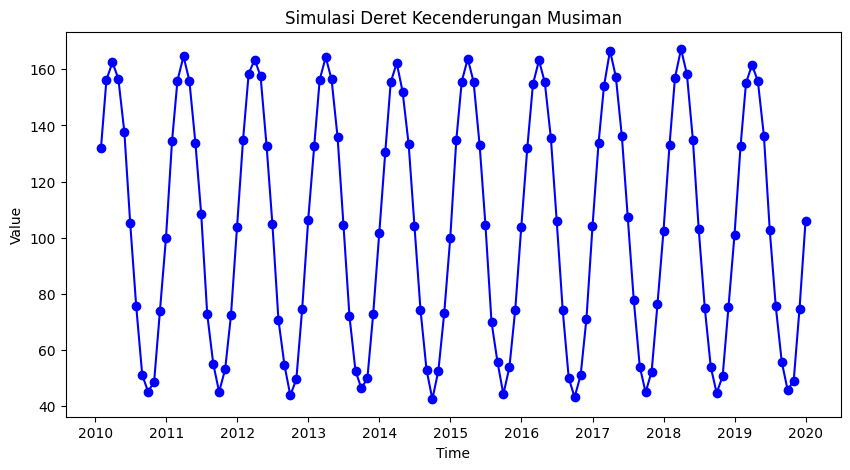

In [19]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12.

In [20]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [21]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [22]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [23]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     6256.
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          5.06e-146
Time:                        06:56:50   Log-Likelihood:                -232.36
No. Observations:                 120   AIC:                             488.7
Df Residuals:                     108   BIC:                             522.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      133.0758      0.559    237.962      0.0

12. Bagaimana interpretasi dari hasil tersebut?\
Jawaban:\
Hasil regresi menunjukkan adanya pola musiman yang cukup jelas pada data. Nilai $R^2$ sebesar 0,998 menunjukkan bahwa model mampu menjelaskan sekitar 99,8% variasi data. Dari koefisien setiap bulan terlihat bahwa nilai deret cenderung meningkat dari Januari hingga mencapai nilai tertinggi pada Maret, kemudian menurun hingga nilai terendah pada September, dan kembali meningkat sampai Desember. Pola ini menunjukkan adanya kecenderungan musiman yang berulang setiap 12 bulan.

In [24]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

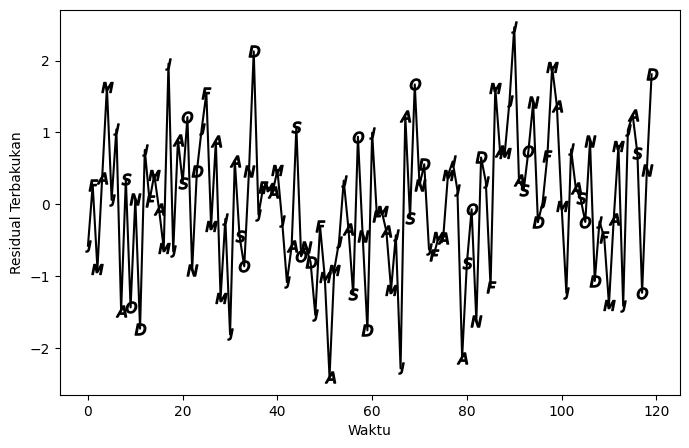

In [25]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


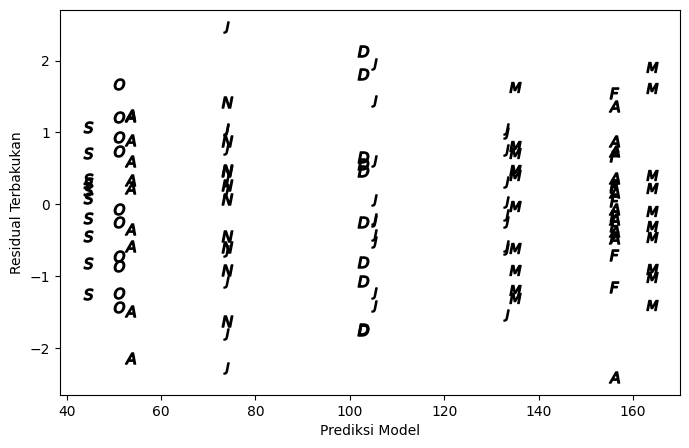

In [26]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

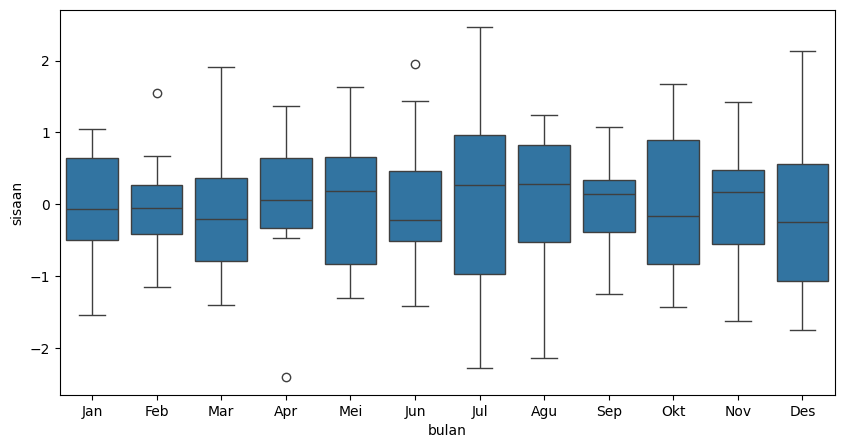

In [27]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

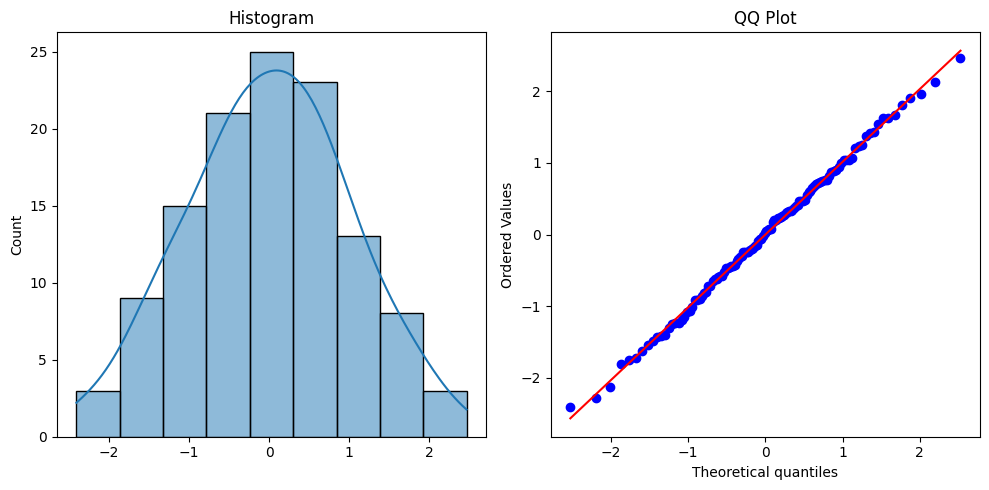

In [28]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

13. Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?\
Jawaban:\
Berdasarkan histogram dan QQ plot, residual terlihat cukup mendekati distribusi normal. Hal ini ditunjukkan oleh bentuk histogram yang relatif simetris dan titik-titik pada QQ plot yang sebagian besar berada di sekitar garis diagonal. Jadi, dari sisi asumsi normalitas, model yang dipaskan sudah cukup baik.


---
14. Hitunglah statistik uji untuk mengecek asumsi model

In [29]:
# Menghitung Uji Statistik untuk Mengecek Asumsi Model
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

# Residual model
residual = musiman.resid

# 1. Uji Normalitas: Shapiro-Wilk
stat_shapiro, p_shapiro = shapiro(residual)

print("Uji Shapiro-Wilk")
print(f"Statistik uji = {stat_shapiro:.4f}")
print(f"P-value = {p_shapiro:.4f}")


# 2. Uji Homoskedastisitas: Breusch-Pagan
X_bp = sm.add_constant(musim.iloc[:, 1:])

print("\nUji Breusch-Pagan")
print(f"Statistik uji = {bp_test[0]:.4f}")
print(f"P-value = {bp_test[1]:.4f}")


# 3. Uji Autokorelasi: Ljung-Box
lb_test = acorr_ljungbox(residual, lags=[12], return_df=True)

print("\nUji Ljung-Box")
print(lb_test)


# 4. Durbin-Watson
dw = durbin_watson(residual)

print("\nDurbin-Watson")
print(f"Statistik uji = {dw:.4f}")

Uji Shapiro-Wilk
Statistik uji = 0.9961
P-value = 0.9865

Uji Breusch-Pagan
Statistik uji = 0.0701
P-value = 0.9656

Uji Ljung-Box
      lb_stat  lb_pvalue
12  10.387546   0.582002

Durbin-Watson
Statistik uji = 1.8751


Dari hasil uji tersebut, secara umum asumsi model musiman sudah terpenuhi.

*   Uji Shapiro-Wilk menghasilkan p-value 0,9865 > 0,05, sehingga residual dapat dianggap berdistribusi normal.
*   Uji Breusch-Pagan menghasilkan p-value 0,8741 > 0,05, sehingga tidak ada indikasi heteroskedastisitas. Artinya, varians residual relatif konstan.
*   Uji Ljung-Box pada lag 12 menghasilkan p-value 0,5820 > 0,05, sehingga tidak terdapat autokorelasi yang signifikan pada residual.
*   Nilai Durbin-Watson sebesar 1,8751 cukup dekat dengan 2, sehingga juga menunjukkan tidak adanya autokorelasi yang kuat.\
Jadi, secara keseluruhan model yang dipaskan sudah cukup baik dan asumsi residualnya terpenuhi.




In [ ]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [30]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [31]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     6256.
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          5.06e-146
Time:                        06:57:55   Log-Likelihood:                -232.36
No. Observations:                 120   AIC:                             488.7
Df Residuals:                     108   BIC:                             522.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        133.0758      0.559    237.962      0.0

15. Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep?\
Jawaban:

Pada model tanpa intersep, semua 12 bulan dimasukkan ke dalam model sehingga nilai koefisien masing-masing bulan langsung menunjukkan rata-rata nilai pada bulan tersebut. Sementara pada model dengan intersep, Januari dijadikan sebagai bulan acuan dan tidak dimasukkan sebagai variabel dummy.

Nilai intersep sebesar 133,0758 menunjukkan rata-rata nilai pada bulan Januari. Koefisien bulan lainnya menunjukkan selisih rata-rata bulan tersebut terhadap Januari. Misalnya, koefisien Februari sebesar 22,8269, artinya nilai pada bulan Februari rata-rata 22,8269 lebih tinggi dibandingkan Januari. Jadi, nilai Februari diperkirakan sebesar:

$$ 133,0758 + 22,8269 = 155,9027 $$

Walaupun cara membaca koefisiennya berbeda, hasil pengepasan model dengan dan tanpa intersep sebenarnya sama. Hal ini terlihat dari nilai $R^2$, AIC, BIC, dan hasil prediksinya yang sama.


---



16. Apakah model dengan intersep sudah memenuhi asumsi regresi?\
Jawaban:

Ya, model dengan intersep sudah memenuhi asumsi regresi. Karena model dengan dan tanpa intersep menghasilkan nilai prediksi dan residual yang sama, hasil pengecekan asumsi juga sama.

Uji Shapiro-Wilk menghasilkan p-value 0,9865 > 0,05, sehingga residual dapat dianggap berdistribusi normal. Uji Breusch-Pagan menghasilkan p-value 0,8741 > 0,05, sehingga tidak terdapat indikasi heteroskedastisitas. Uji Ljung-Box juga menghasilkan p-value 0,5820 > 0,05, yang menunjukkan tidak adanya autokorelasi yang signifikan. Hal ini juga didukung oleh nilai Durbin-Watson sebesar 1,8751 yang cukup dekat dengan 2.

Jadi, secara keseluruhan model dengan intersep sudah memenuhi asumsi regresi.

In [ ]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [32]:
# Parameter
np.random.seed(1054)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5 + 54, 10 + 54 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


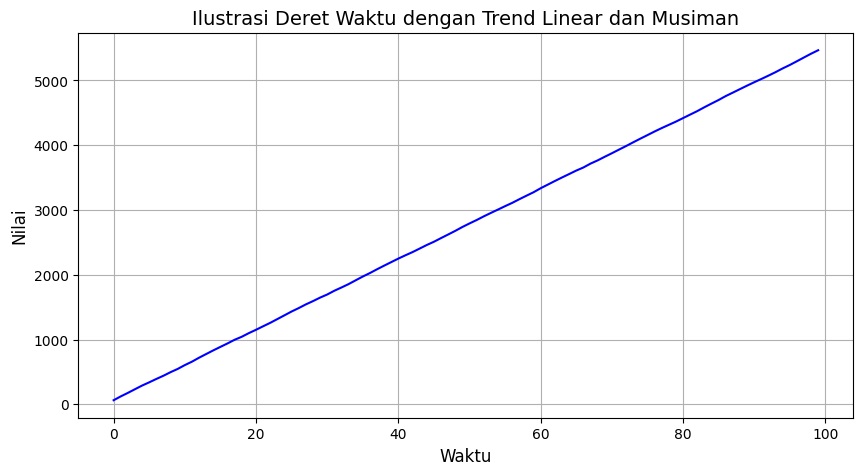

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [34]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [35]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [36]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.440e+06
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          3.13e-253
Time:                        06:58:28   Log-Likelihood:                -193.13
No. Observations:                 100   AIC:                             412.3
Df Residuals:                      87   BIC:                             446.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       63.8108      0.667     95.672      0.0

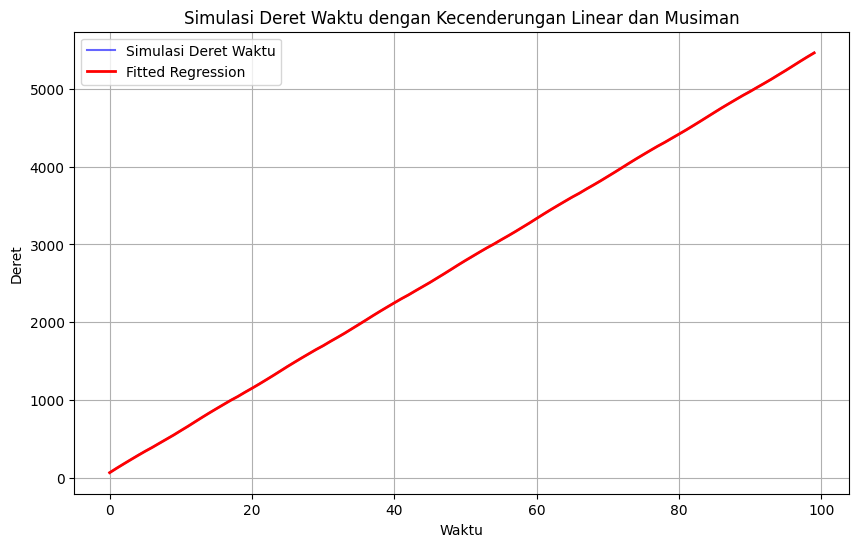

In [37]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model!

In [38]:
# uji asumsi model
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

# Residual
residual_mix = model_mix.resid

# 1. Shapiro-Wilk
stat_shapiro, p_shapiro = shapiro(residual_mix)

print("=== Uji Shapiro-Wilk ===")
print(f"Statistik uji = {stat_shapiro:.4f}")
print(f"P-value       = {p_shapiro:.4f}")

# 2. Breusch-Pagan
X_bp = season.drop(columns=['Januari'])
X_bp = sm.add_constant(X_bp)

bp_test = het_breuschpagan(residual_mix, X_bp)

print("\n=== Uji Breusch-Pagan ===")
print(f"LM Statistic = {bp_test[0]:.4f}")
print(f"P-value      = {bp_test[1]:.4f}")


# 3. Ljung-Box
lb_test = acorr_ljungbox(
    residual_mix,
    lags=[12],
    return_df=True
)

print("\n=== Uji Ljung-Box ===")
print(lb_test)

# 4. Durbin-Watson
dw = durbin_watson(residual_mix)

print("\n=== Durbin-Watson ===")
print(f"Statistik uji = {dw:.4f}")

=== Uji Shapiro-Wilk ===
Statistik uji = 0.9950
P-value       = 0.9742

=== Uji Breusch-Pagan ===
LM Statistic = 10.2384
P-value      = 0.5951

=== Uji Ljung-Box ===
      lb_stat  lb_pvalue
12  12.178705   0.431437

=== Durbin-Watson ===
Statistik uji = 1.8395


Dari hasil uji asumsi tersebut, model kecenderungan linear dan musiman sudah memenuhi asumsi regresi.

- Uji Shapiro-Wilk menghasilkan p-value 0,9742 > 0,05, jadi residual dapat dianggap berdistribusi normal.
- Uji Breusch-Pagan menghasilkan p-value 0,5951 > 0,05, sehingga tidak terdapat indikasi heteroskedastisitas. Artinya, varians residual relatif konstan.
- Uji Ljung-Box menghasilkan p-value 0,4314 > 0,05, sehingga tidak terdapat autokorelasi yang signifikan pada residual.
- Durbin-Watson = 1,8395, nilainya cukup dekat dengan 2, sehingga tidak menunjukkan adanya autokorelasi yang kuat.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [39]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

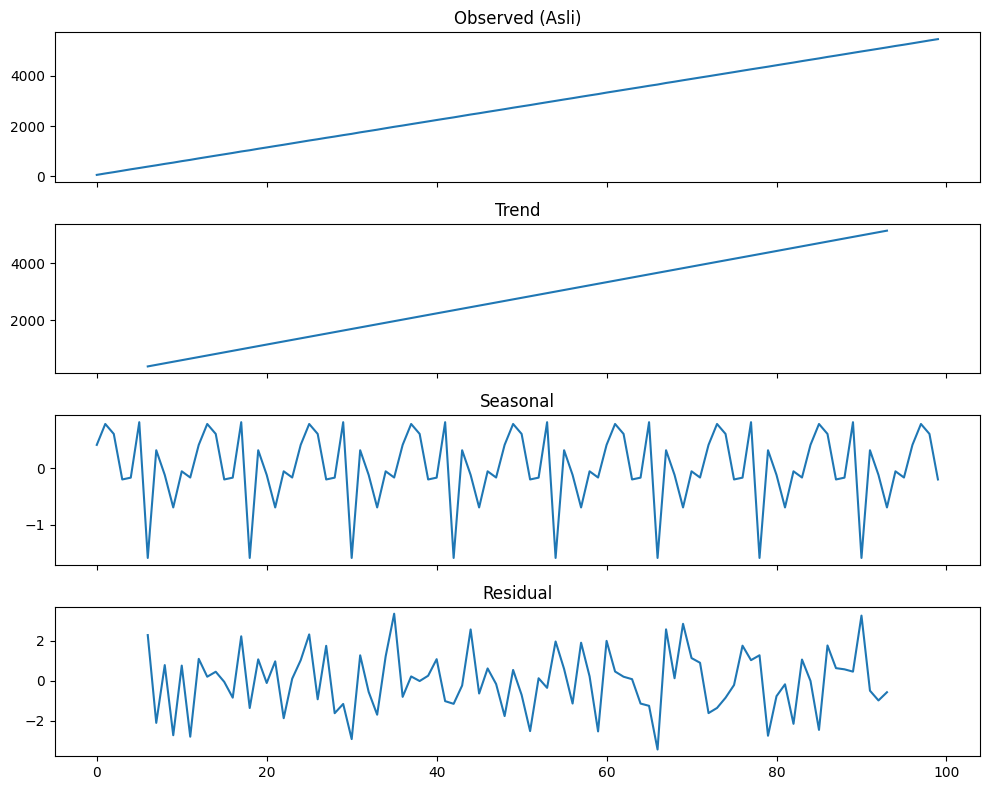

In [40]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

17. Bagaimana interpretasi hasil dekomposisi deret tersebut?

Jawaban:

Hasil dekomposisi menunjukkan bahwa deret memiliki kecenderungan meningkat secara linear dan juga memiliki pola musiman yang berulang setiap 12 periode. Setelah komponen trend dan musiman dipisahkan, residual terlihat berfluktuasi di sekitar nol tanpa pola yang jelas. Hal ini menunjukkan bahwa komponen trend dan musiman sudah cukup mampu menggambarkan pola utama pada deret tersebut.

In [41]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

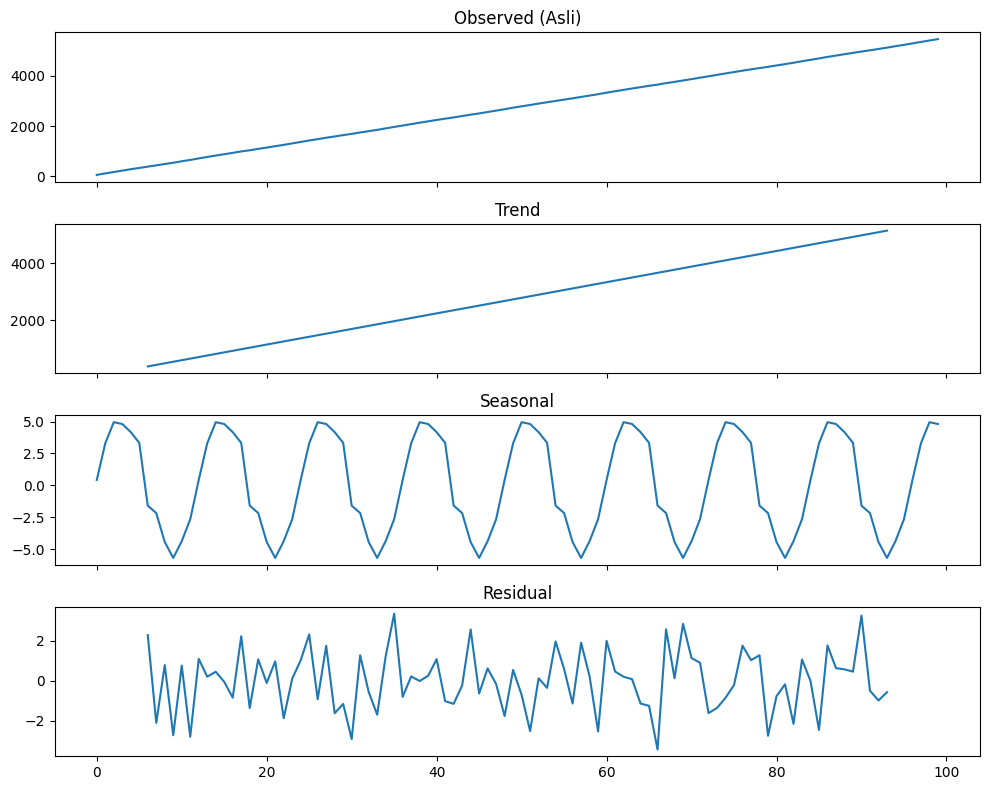

In [42]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


18. Bagaimana interpretasi hasil dekomposisi deret tersebut?

Jawaban:

Hasil dekomposisi menunjukkan bahwa deret memiliki kecenderungan meningkat secara linear dan terdapat pola musiman yang berulang setiap 12 periode. Komponen musiman terlihat memiliki pola naik dan turun yang cukup teratur. Sementara itu, residual berfluktuasi di sekitar nol tanpa pola yang jelas. Jadi, pola utama pada deret sudah cukup dijelaskan oleh komponen trend dan musiman.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [43]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1054)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05 + 54, 10 + 54 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

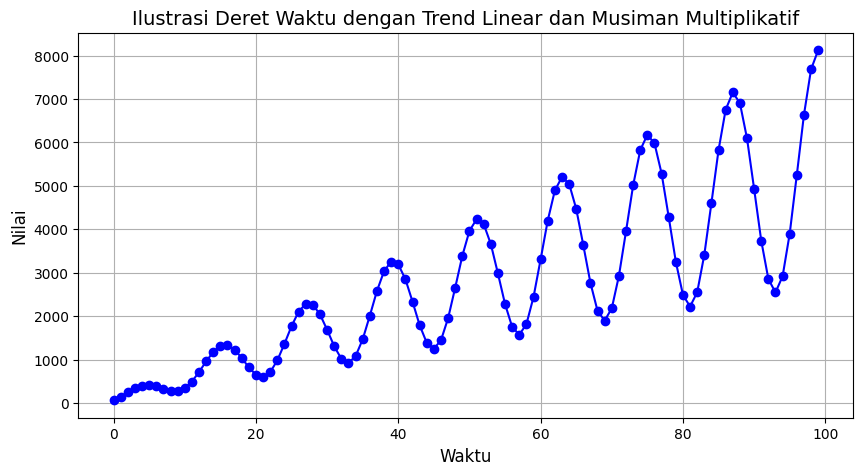

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [45]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

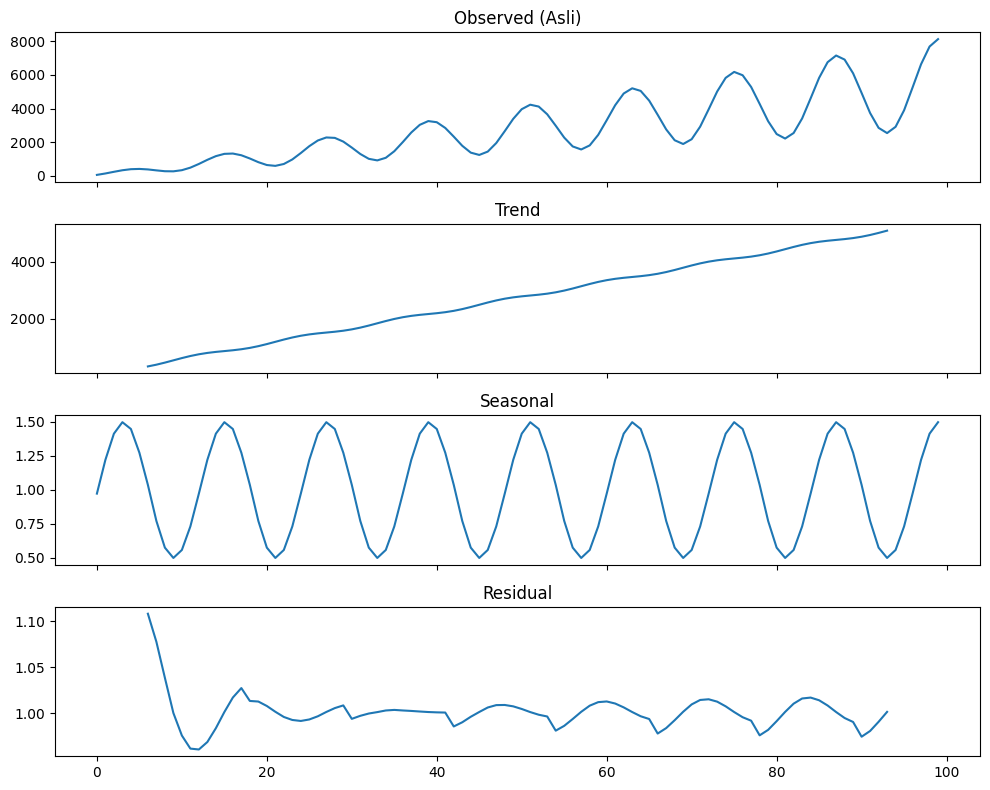

In [46]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

In [47]:
# Parameter
np.random.seed(1054)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

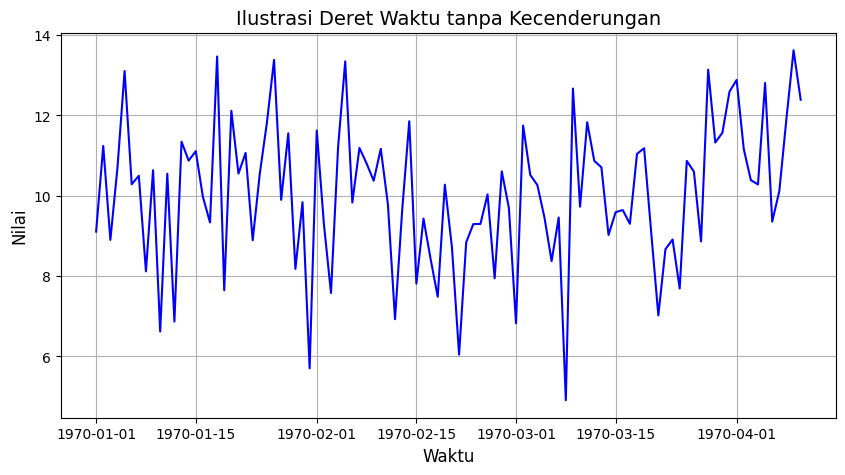

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

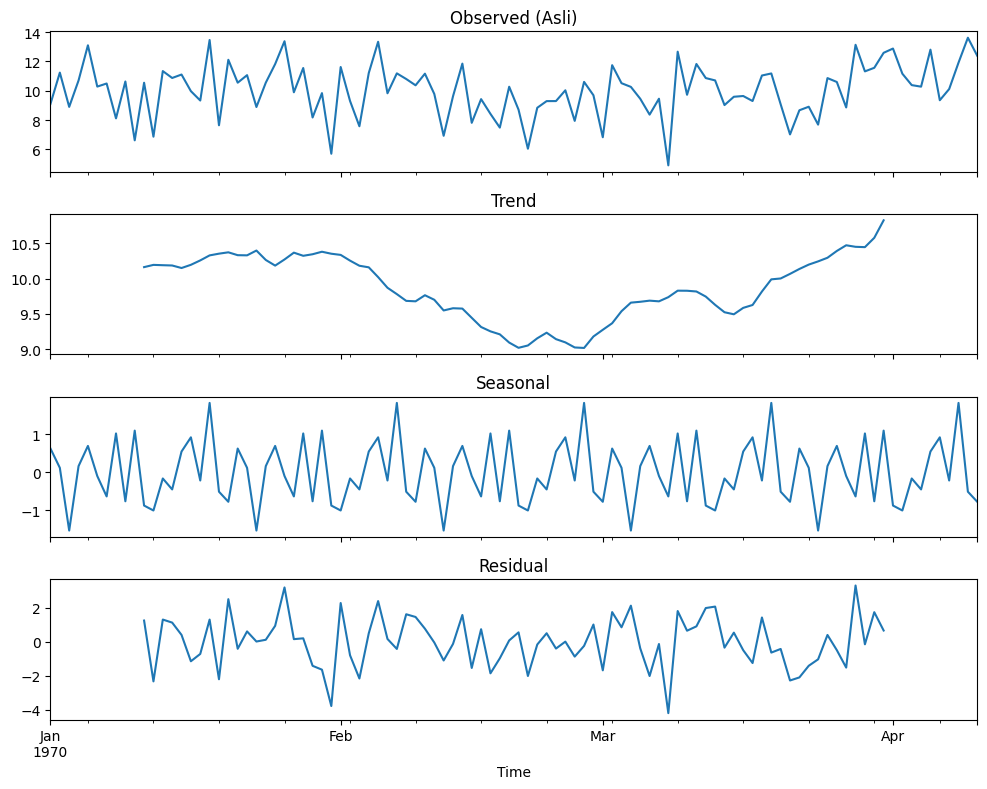

In [49]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()